# First Day Quantum Computing Lab

## Understanding Superposition, Measurement, Entanglement, and the Bloch Sphere

This notebook is designed as a **first-day programming activity** for students beginning quantum computing with Qiskit.

### What you will learn
By the end of this lab, you should be able to:
- build a simple quantum circuit
- create a superposition state
- run a circuit on a simulator and interpret measurement counts
- create a basic entangled state
- connect one-qubit states to the **Bloch Sphere**
- explain what common gates such as **H**, **X**, and **Z** do to a qubit

### How to use this notebook
For each section:
1. Read the explanation.
2. Run the code.
3. Answer the short activity questions.
4. Modify the code where asked and observe what changes.


## 1. Setup

The next cell imports the main Qiskit tools used in this notebook.

- `QuantumCircuit` is used to build circuits.
- `AerSimulator` runs the circuit on a simulator.
- `plot_histogram` helps us visualise measurement outcomes.
- `Statevector` lets us examine the state before measurement.
- `plot_bloch_multivector` helps us visualise a single-qubit state on the Bloch Sphere.


In [ ]:
!pip install qiskit qiskit_aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 11.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.3 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=4042185f474a32dadcf555055b046818756bd7b0ad3062ac695ec696ab039cda
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
import qiskit as qk
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
import numpy as np
import math

# Uncomment this line if needed in Jupyter
# %matplotlib inline

## 2. Warm-up: a qubit in superposition

A classical bit must be either **0** or **1**.

A qubit can also be in a **superposition** of both basis states.  
One of the easiest ways to create superposition is to apply a **Hadamard gate (`H`)** to \(|0\rangle\).

### What should happen?
If we apply `H` to a qubit that starts in \(|0\rangle\), the state becomes:

\[
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
\]

When measured many times, we expect roughly:
- 50% outcome `0`
- 50% outcome `1`


Circuit:


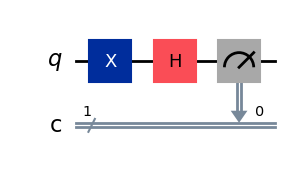

Measurement counts: {'1': 519, '0': 505}


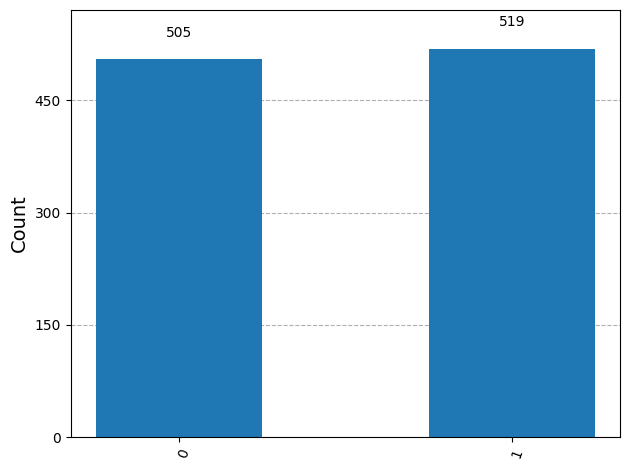

In [ ]:
# Example 1: One qubit in superposition
qc1 = QuantumCircuit(1, 1)

# Apply Hadamard gate
qc1.x(0)
qc1.h(0)

# Measure the qubit
qc1.measure(0, 0)

print("Circuit:")
display(qc1.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc1, shots=1024)
result = job.result()
counts = result.get_counts(qc1)

print("Measurement counts:", counts)
plot_histogram(counts)

### Class activity 1
Answer these questions after running the cell above:

1. Why do we not get only `0` as the result?
2. Are the counts exactly equal? Why or why not?
3. What do you think will happen if the `H` gate is removed?

### Try it yourself
Modify the circuit:
- remove the `H` gate and run again
- replace `qc1.h(0)` with `qc1.x(0)` and run again

Write one sentence explaining each outcome.


## 3. Two qubits in superposition

Now let us extend the idea to **two qubits**.

If we apply a Hadamard gate to both qubits, each qubit goes into superposition independently.  
After measurement, we expect to see four possible outcomes:

- `00`
- `01`
- `10`
- `11`

Each should appear with roughly equal probability.


Circuit:


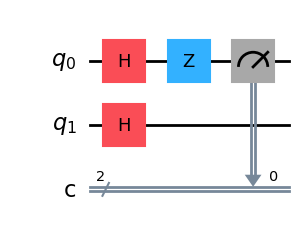

Measurement counts: {'01': 511, '00': 513}


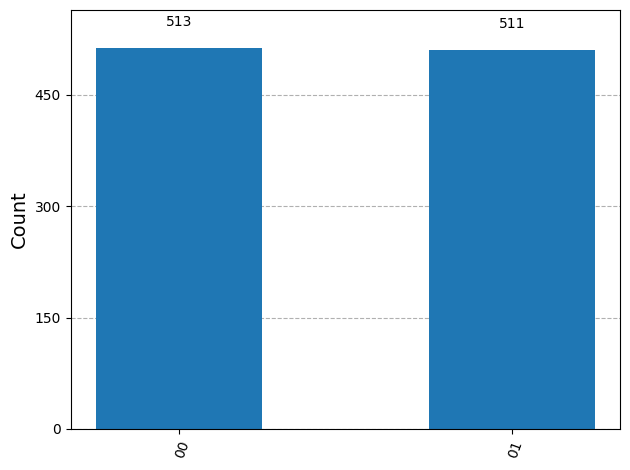

In [ ]:
# Example 2: Two qubits in superposition
qc2 = qk.QuantumCircuit(2, 2)

qc2.h(0)
qc2.h(1)

qc2.z(0)

qc2.measure(0, 0)
#qc2.measure(1, 1)

print("Circuit:")
display(qc2.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc2, shots=1024)
result = job.result()
counts = result.get_counts(qc2)

print("Measurement counts:", counts)
plot_histogram(counts)

### Class activity 2
Discuss with a partner:

1. Why are there four possible outputs now?
2. Which output appears most often? Is that what you expected?
3. If you apply `X` to qubit 0 before the `H`, how does the result change?

### Extension
Try the following one at a time:
- apply `X` on qubit 0 before measurement
- apply `Z` on qubit 0 before measurement
- measure only one qubit and leave the other unmeasured

What do you observe?


## 4. Entanglement

Entanglement is one of the most important ideas in quantum computing.

In this section, we create an entangled pair using:
1. a **Hadamard** gate on the first qubit
2. a **CNOT** gate from the first qubit to the second

This creates the Bell state:

\[
\frac{|00\rangle + |11\rangle}{\sqrt{2}}
\]

### What should happen?
When measured many times, the outcomes should be mostly:
- `00`
- `11`

The key point is that the two qubits are **correlated**.


Circuit:


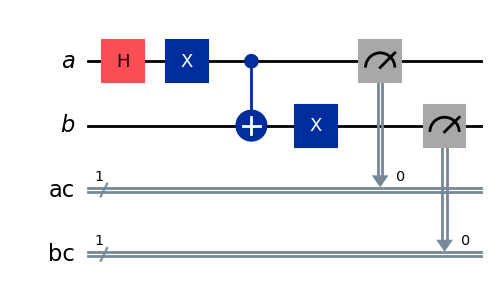

Measurement counts: {'1 0': 2071, '0 1': 2025}


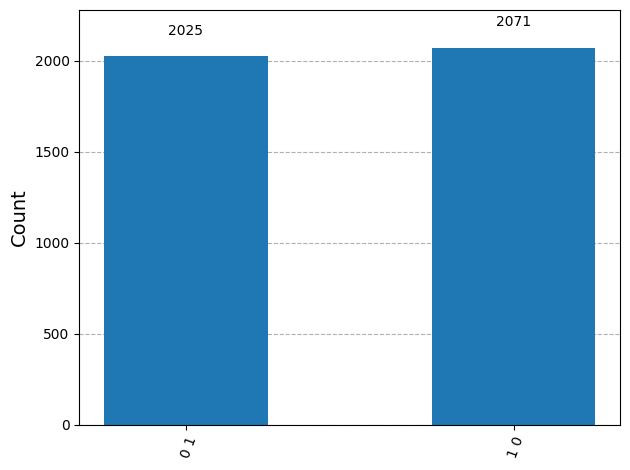

In [ ]:
# Example 3: Entangled qubits
a = QuantumRegister(1, name='a')
b = QuantumRegister(1, name='b')
a_c = ClassicalRegister(1, name='ac')
b_c = ClassicalRegister(1, name='bc')

qc3 = QuantumCircuit(a, b, a_c, b_c)

qc3.h(a[0])          # put qubit a into superposition
qc3.x(a[0])
qc3.cx(a[0], b[0])   # entangle qubit a and qubit b

qc3.x(b[0])

qc3.measure(a[0], a_c[0])
qc3.measure(b[0], b_c[0])

print("Circuit:")
display(qc3.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc3, shots=4096)
result = job.result()
counts = result.get_counts(qc3)

print("Measurement counts:", counts)
plot_histogram(counts)

### Class activity 3
After running the entanglement example, answer:

1. Why do we mainly see `00` and `11`, but not `01` and `10`?
2. How is this different from the earlier two-qubit superposition example?
3. What role does the `cx` gate play?

### Try it yourself
Change the circuit and test:
- remove the `cx` gate
- apply `x` to qubit `b` before measurement
- apply `z` to qubit `a` before the `cx`

Describe what changes in the histogram.


## 5. Bloch Sphere intuition for a single qubit

The **Bloch Sphere** is a visual way to represent the state of **one qubit**.

### Key reference points
- \(|0\rangle\) is at the **north pole**
- \(|1\rangle\) is at the **south pole**
- superposition states lie at other points on the sphere
- pure states lie on the **surface** of the sphere

You can think of common gates as rotations or flips on this sphere.


Statevector for |0>: Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


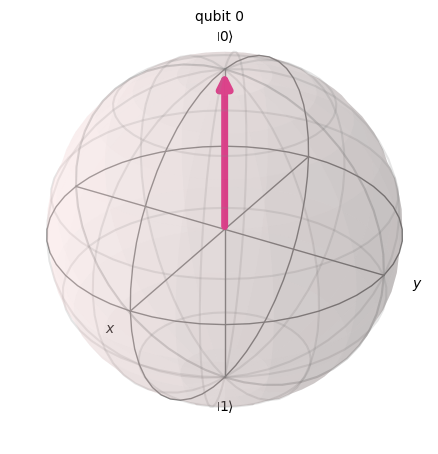

In [ ]:
# Bloch Sphere for |0>
qc_b0 = QuantumCircuit(1)
state_b0 = Statevector.from_instruction(qc_b0)

print("Statevector for |0>:", state_b0)
plot_bloch_multivector(state_b0)

Statevector for |1>: Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


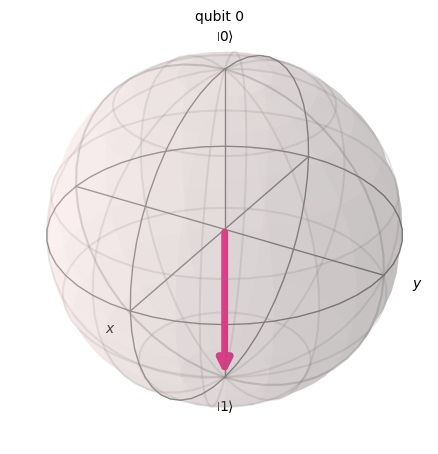

In [ ]:
# Bloch Sphere for |1>
qc_b1 = QuantumCircuit(1)
qc_b1.x(0)
state_b1 = Statevector.from_instruction(qc_b1)

print("Statevector for |1>:", state_b1)
plot_bloch_multivector(state_b1)

Statevector for H|0>: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


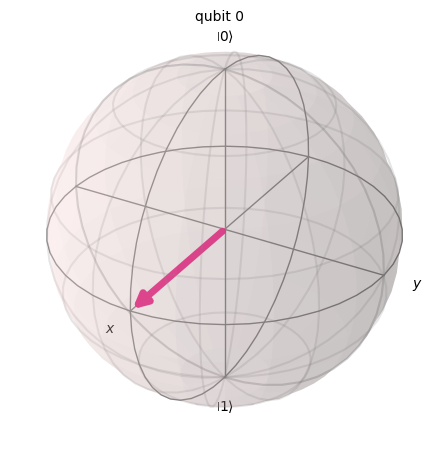

In [ ]:
# Bloch Sphere for H|0>
qc_bh = QuantumCircuit(1)
qc_bh.h(0)
state_bh = Statevector.from_instruction(qc_bh)

print("Statevector for H|0>:", state_bh)
plot_bloch_multivector(state_bh)

### Class activity 4
For each state above, identify whether the point is:
- near the north pole
- near the south pole
- on the equator

Then answer:
1. Where is \(|0\rangle\)?
2. Where is \(|1\rangle\)?
3. What type of state is created by `H|0>`?
4. Why is the Bloch Sphere mainly useful for only one qubit?


## 6. Gate effects on the Bloch Sphere

Now let us see how gates move a state around the sphere.

### Predictions before running
Before you run each cell, predict what will happen:
- Will the state flip from top to bottom?
- Will it remain on the equator?
- Will it rotate around an axis?


Statevector after X|0>: Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


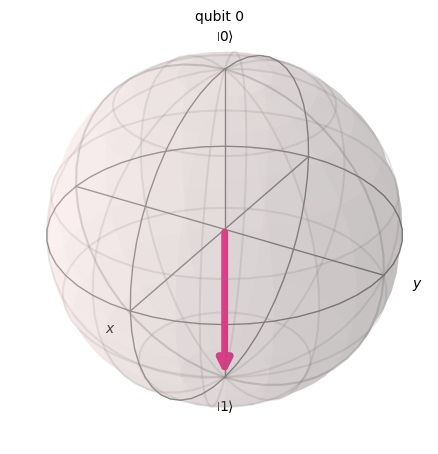

In [ ]:
# X gate on |0>
qc_x = QuantumCircuit(1)
qc_x.x(0)
state_x = Statevector.from_instruction(qc_x)

print("Statevector after X|0>:", state_x)
plot_bloch_multivector(state_x)

Statevector after ZH|0>: Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


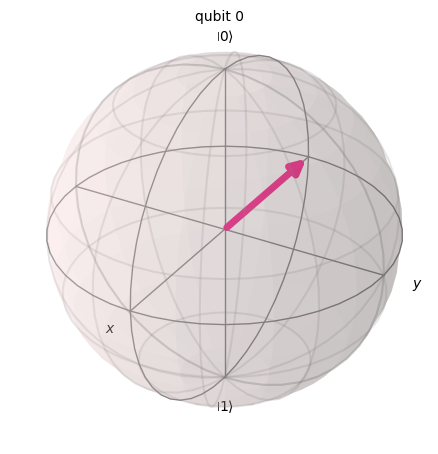

In [ ]:
# Z gate after H
qc_z = QuantumCircuit(1)
qc_z.x(0)
qc_z.h(0)
#qc_z.z(0)
state_z = Statevector.from_instruction(qc_z)

print("Statevector after ZH|0>:", state_z)
plot_bloch_multivector(state_z)

Statevector after XH|0>: Statevector([0.70710678+0.j , 0.5       +0.5j],
            dims=(2,))


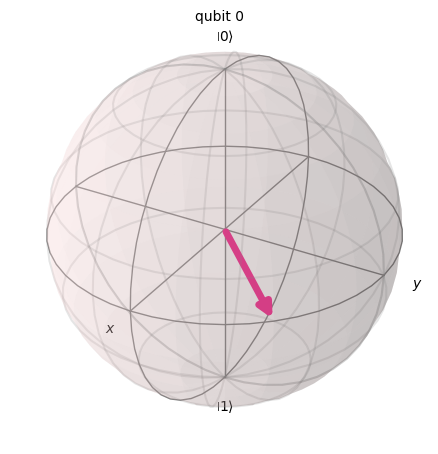

In [ ]:
# H followed by X
qc_hx = QuantumCircuit(1)

qc_hx.h(0)
qc_hx.t(0)

state_hx = Statevector.from_instruction(qc_hx)

print("Statevector after XH|0>:", state_hx)
plot_bloch_multivector(state_hx)

### Class activity 5
Complete the table below in your notes.

| Circuit | Your prediction | What you observed |
|---|---|---|
| `X|0>` |  |  |
| `ZH|0>` |  |  |
| `XH|0>` |  |  |

Then answer:
1. Which gate produced a clear flip between \(|0\rangle\) and \(|1\rangle\)?
2. Which gate changed the phase of a superposition state?
3. Why can two states give different Bloch positions even when probabilities may look similar?


## 7. Student mini-challenge

Create your own one-qubit circuit using any combination of:
- `h`
- `x`
- `y`
- `z`
- `s`
- `t`

### Your task
1. Build a circuit with at least **two gates**.
2. Predict the Bloch Sphere position before running it.
3. Plot the Bloch Sphere.
4. Write a 3 to 5 line explanation of what happened.
- H: Rotate 90 degrees counterclockwise about the y-axis
- X: Rotate 180 degrees counterclockwise about the x-axis
- Y: Rotate 180 degrees counterclockwise about the y-axis
- Z: Rotate 180 degrees counterclockwise about the z-axis
- S: Rotate 90 degrees counterclockwise about the z-axis
- T: Rotate 45 degrees counterclockwise about the z-axis

Use the cell below.


Your circuit:


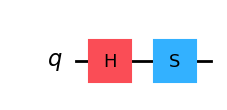

Statevector: Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))


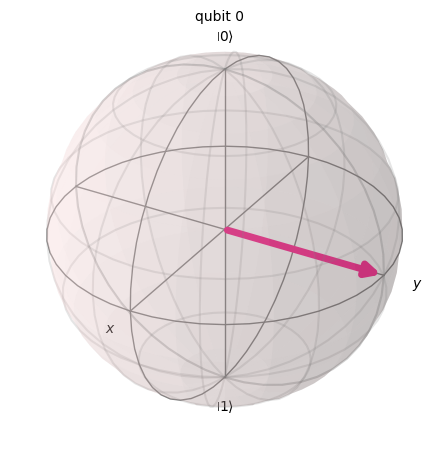

In [ ]:
# Student challenge cell
qc_student = QuantumCircuit(1)

# Example: replace these with your own gates
qc_student.h(0)
qc_student.s(0)

print("Your circuit:")
display(qc_student.draw(output='mpl'))

state_student = Statevector.from_instruction(qc_student)
print("Statevector:", state_student)
plot_bloch_multivector(state_student)

## 8. Reflection questions

Write short answers for the following:

1. What is the difference between a classical bit and a qubit?
- classical bit is either 0 or 1
- qubit can be in superposition with probablity of 0 and 1
2. What does the Hadamard gate do?
- turn a classical bit into superposition
3. How is an entangled state different from two independent qubits in superposition?
- qubit in entangled state can affect the other qubit
4. What does the Bloch Sphere help us understand?
- understand amplitude and phase of 1 qubit and how the gates affect the amplitude and phase.
5. Which part of today's lab did you find the most interesting or confusing?
- Bloch Sphere is an amazing tool for qubit understanding


## 9. Optional assessment task

Submit the following:
- one screenshot of a circuit you created
- one histogram or Bloch Sphere output
- a short explanation of what your circuit does

### Suggested marking focus
- correctness of circuit
- interpretation of results
- ability to connect code with concept
